In [39]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from opacus import PrivacyEngine

In [40]:
df = pd.read_csv("Final_Depression3_anonymised.csv")
print("Shape:", df.shape)
df.head()

Shape: (11702, 39)


,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,orientation,race,...,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Condition
0,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,3,4,7,6,4,6,5,1,2,Extremely Severe
1,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,3,5,6,6,3,6,6,2,1,Normal
2,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,6,3,3,6,3,7,6,3,1,Moderate
3,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,5,1,7,3,4,3,7,1,2,Extremely Severe
4,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,5,2,5,5,4,5,6,2,2,Moderate


In [41]:
import pandas as pd

df = pd.read_csv("Final_Depression3_anonymised.csv")

# Depression-related DASS questions
depression_qs = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A',
                 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']

# Score processing
depression_df = df[depression_qs].apply(pd.to_numeric, errors='coerce') - 1
depression_df['Total_Count'] = depression_df.sum(axis=1)

def get_condition(score):
    if score <= 9:
        return 'Normal'
    elif 10 <= score <= 13:
        return 'Mild'
    elif 14 <= score <= 20:
        return 'Moderate'
    elif 21 <= score <= 27:
        return 'Severe'
    else:
        return 'Extremely Severe'

# Label the condition
df['Condition'] = depression_df['Total_Count'].apply(get_condition)


In [42]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}
target_column = 'Condition'

# Encode all categorical columns except the target
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Encode the target as well
le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])

# Now split from df_encoded
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



In [43]:
# Check and encode any remaining non-numeric features
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])

# Now retry SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [44]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to PyTorch tensors (make sure all are numeric)
X_train_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [45]:
# !pip install diffprivlib
# !pip install imbalanced-learn

In [46]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = MLP(input_dim, num_classes)




In [47]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# privacy_engine = PrivacyEngine()
# model, optimizer, train_loader = privacy_engine.make_private(
#     module=model,
#     optimizer=optimizer,
#     data_loader=train_loader,
#     noise_multiplier=1.0,
#     max_grad_norm=1.0,
# )


In [48]:
best_val_loss = float('inf')
patience = 25         # Stop after 3 epochs of no improvement
counter = 0
max_epochs = 50       # Max cap in case it doesn't converge

for epoch in range(max_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    print(f"Epoch {epoch+1} - Training Loss: {total_loss:.4f} - Validation Loss: {val_loss:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "trained_mlp_model.pth")  # Save best model
        print("New best model saved!")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping: No improvement for 3 consecutive epochs.")
            break


Epoch 1 - Training Loss: 181.1055 - Validation Loss: 0.4839
New best model saved!
Epoch 2 - Training Loss: 115.4749 - Validation Loss: 0.4285
New best model saved!
Epoch 3 - Training Loss: 103.6159 - Validation Loss: 0.3854
New best model saved!
Epoch 4 - Training Loss: 100.6849 - Validation Loss: 0.3799
New best model saved!
Epoch 5 - Training Loss: 93.7499 - Validation Loss: 0.3368
New best model saved!
Epoch 6 - Training Loss: 90.6699 - Validation Loss: 0.3982
Epoch 7 - Training Loss: 88.9825 - Validation Loss: 0.4870
Epoch 8 - Training Loss: 86.8232 - Validation Loss: 0.3483
Epoch 9 - Training Loss: 82.6664 - Validation Loss: 0.3471
Epoch 10 - Training Loss: 80.8829 - Validation Loss: 0.3274
New best model saved!
Epoch 11 - Training Loss: 80.3494 - Validation Loss: 0.3748
Epoch 12 - Training Loss: 79.7042 - Validation Loss: 0.3265
New best model saved!
Epoch 13 - Training Loss: 76.4349 - Validation Loss: 0.4286
Epoch 14 - Training Loss: 74.5272 - Validation Loss: 0.3474
Epoch 15 - 

In [49]:
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).argmax(dim=1)
    y_val_pred = model(X_val_tensor).argmax(dim=1)

train_acc = accuracy_score(y_train_tensor, y_train_pred)
val_acc = accuracy_score(y_val_tensor, y_val_pred)

print(f"\n Training Accuracy: {train_acc:.4f}")
print(f" Validation Accuracy: {val_acc:.4f}\n")

print("Classification Report (Validation):")
print(classification_report(y_val_tensor, y_val_pred, target_names=[str(c) for c in le_target.classes_]))


# epsilon = privacy_engine.accountant.get_epsilon(delta=1e-5)
# print(f"\n Differential Privacy Epsilon: {epsilon:.2f} (δ=1e-5)")




 Training Accuracy: 0.8896
 Validation Accuracy: 0.8026

Classification Report (Validation):
                  precision    recall  f1-score   support

Extremely Severe       0.90      0.99      0.95       788
            Mild       0.47      0.52      0.49       224
        Moderate       0.73      0.69      0.71       422
          Normal       0.99      0.75      0.85       524
          Severe       0.69      0.77      0.73       383

        accuracy                           0.80      2341
       macro avg       0.76      0.74      0.75      2341
    weighted avg       0.81      0.80      0.80      2341



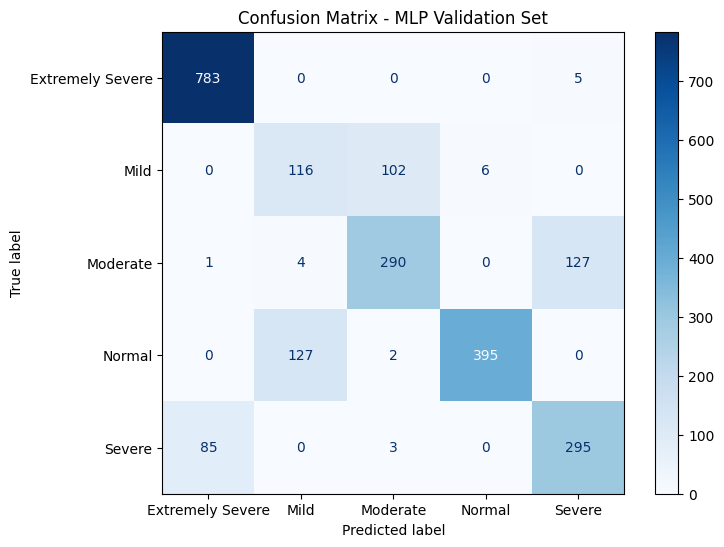

In [50]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# STEP 1: Predict using the trained MLP model
model.eval()
with torch.no_grad():
    y_val_logits = model(X_val_tensor)
    y_val_pred = torch.argmax(y_val_logits, dim=1).cpu().numpy()

# STEP 2: Optional - decode integer labels to original class names if you used LabelEncoder
class_labels = [str(cls) for cls in le_target.classes_]  # Converts int64 to string labels

# STEP 3: Generate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# STEP 4: Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - MLP Validation Set")
plt.show()


In [51]:
import numpy as np
import torch

In [52]:
# Simulate a dummy gradient from a layer (e.g., 5 parameters)
local_gradient = torch.tensor([0.25, -0.3, 0.1, 0.55, -0.12], dtype=torch.float32)

print("Original Gradient (Local Model):")
print(local_gradient.numpy())


Original Gradient (Local Model):
[ 0.25 -0.3   0.1   0.55 -0.12]


In [53]:
import torch

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [54]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

# Get one batch from your train loader
X_sample, y_sample = next(iter(train_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)


In [55]:
# !pip install flask

In [56]:
import torch
import pickle
import requests
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# Gradient Flattening
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    print(f"[DEBUG] Flattened gradient length: {len(flat)}")
    return flat

# -------------------------------
# Send Raw Chunks to Server
# -------------------------------
def send_raw_chunks_binary(flattened_grads, server_url, client_id="hospital_3", chunk_size=8000):
    chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    for i, chunk in enumerate(chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,
                'data': chunk.numpy()  # Raw NumPy array
            }
            data = pickle.dumps(payload)

            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False  # Allow self-signed cert
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

# -------------------------------
# Client Main Routine
# -------------------------------
def run_client_post_training(model, server_url="https://127.0.0.1:5055", client_id="hospital_3"):
    print("[CLIENT] Preparing gradients...")
    grads = flatten_gradients(model)

    # (Optional) Uncomment to simulate Byzantine attack
    # grads = make_byzantine_gradients(grads, strategy="flip")

    print("[CLIENT] Sending raw gradients...")
    send_raw_chunks_binary(grads, server_url=server_url, client_id=client_id)

run_client_post_training(model)


[CLIENT] Preparing gradients...
[DEBUG] Flattened gradient length: 13573
[CLIENT] Sending raw gradients...
[CLIENT] Sent chunk 0 (27349 bytes)
[CLIENT] Sent chunk 1 (27345 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [57]:
import torch
import torch.nn as nn
import pickle
from sklearn.metrics import classification_report
import warnings
import os
import requests

warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# Define MLP Architecture
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------
# Evaluate Model
# -------------------------------
def evaluate_model(model, dataloader, criterion, split_name="Validation"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = 100.0 * correct / total
    print(f"[CLIENT] {split_name} → Accuracy: {acc:.2f}%, Loss: {total_loss:.4f}")
    return all_preds, all_labels, total_loss

# -------------------------------
# Flatten Gradients with Clipping
# -------------------------------
def flatten_and_clip_gradients(model, clip_norm=1e2):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)

    grad_norm = flat.norm()
    if grad_norm > clip_norm:
        flat = flat / grad_norm * clip_norm
        print(f"[CLIENT] Gradient clipped to norm {clip_norm} (original norm: {grad_norm:.2e})")
    else:
        print(f"[CLIENT] Gradient norm OK: {grad_norm:.2e}")
    
    return flat

# -------------------------------
# Send Gradients via Binary (No HE)
# -------------------------------
def send_gradients_binary(flattened_grads, server_url, client_id="hospital_3", chunk_size=8000):
    chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    for i, chunk in enumerate(chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,
                'data': chunk.numpy()  
            }
            data = pickle.dumps(payload)
            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

def apply_global_gradient(model, global_gradient_file="aggregated_gradient_global_raw.pkl"):
    if not os.path.exists(global_gradient_file):
        print(f"[CLIENT] Global gradient file '{global_gradient_file}' not found.")
        return

    with open(global_gradient_file, "rb") as f:
        aggregated_chunks = pickle.load(f)

    # Reconstruct the full gradient
    global_grad = torch.cat([torch.tensor(chunk, dtype=torch.float32) for chunk in aggregated_chunks])
    print(f"[CLIENT] Loaded global gradient of length: {len(global_grad)}")

    # Apply to model
    pointer = 0
    for param in model.parameters():
        if param.grad is not None:
            shape = param.grad.shape
            size = param.grad.numel()
            param.data -= global_grad[pointer:pointer + size].view(shape)
            pointer += size

    print("[CLIENT] Applied global aggregated gradient to model")

    # Delete after applying to avoid reuse
    try:
        os.remove(global_gradient_file)
        print(f"[CLIENT] Deleted global gradient file: {global_gradient_file}")
    except Exception as e:
        print(f"[CLIENT] Failed to delete global gradient file: {e}")


# -------------------------------
# Main Federated Loop
# -------------------------------
sample_batch, _ = next(iter(train_loader))
input_dim = sample_batch.shape[1]
global_model = MLP(input_dim=input_dim, output_dim=5)

state_dict = torch.load("trained_mlp_model.pth")
fixed_state_dict = {k.replace("_module.", ""): v for k, v in state_dict.items()}
global_model.load_state_dict(fixed_state_dict, strict=False)
print("[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(global_model.parameters(), lr=0.01)

best_val_loss = float('inf')
patience = 3
counter = 0
max_rounds = 50

for round in range(max_rounds):
    print(f"\n === Federated Round {round+1} ===")

    # STEP 1: Local training
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 2: Wait for global gradient aggregation
    user_in = input("Press Enter once server has aggregated and saved global gradient (or type 'exit'): ").strip().lower()
    if user_in == "exit":
        print("Exiting federated training loop.")
        break

    # STEP 3: Apply global gradient (No HE)
    apply_global_gradient(global_model)


    # STEP 4: Re-train model (after receiving updated global model)
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 5: Compute & send new gradients
    grads = flatten_and_clip_gradients(global_model)
    print(f"[CLIENT] Flattened & clipped gradient vector length: {len(grads)}")
    send_gradients_binary(grads, server_url="https://127.0.0.1:5055", client_id="hospital_3")

    # STEP 6: Evaluation
    evaluate_model(global_model, train_loader, criterion, "Training")
    val_preds, val_labels, val_loss = evaluate_model(global_model, val_loader, criterion, "Validation")
    print("[CLIENT] Validation Classification Report:")
    print(classification_report(val_labels, val_preds, zero_division=0))

    # STEP 7: Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(global_model.state_dict(), "trained_global_model_3.pth")
        print("Best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'

 === Federated Round 1 ===


Press Enter once server has aggregated and saved global gradient (or type 'exit'):  


[CLIENT] Loaded global gradient of length: 13573
[CLIENT] Applied global aggregated gradient to model
[CLIENT] Deleted global gradient file: aggregated_gradient_global_raw.pkl
[CLIENT] Gradient norm OK: 4.22e+00
[CLIENT] Flattened & clipped gradient vector length: 13573
[CLIENT] Sent chunk 0 (27349 bytes)
[CLIENT] Sent chunk 1 (27345 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Training → Accuracy: 72.26%, Loss: 156.5907
[CLIENT] Validation → Accuracy: 75.99%, Loss: 21.4406
[CLIENT] Validation Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       788
           1       0.41      0.91      0.57       224
           2       0.64      0.75      0.69       422
           3       0.98      0.64      0.77       524
           4       0.79      0.48      0.60       383

    accuracy                           0.76      2341
   macro avg       0.76      0.74      0.71      2341
weighted avg       0.82      0.76      0.77      2341

Best model saved.

 === Federated Round 2 ===


...

[CLIENT] Loaded global gradient of length: 13573
[CLIENT] Applied global aggregated gradient to model
[CLIENT] Deleted global gradient file: aggregated_gradient_global_raw.pkl
[CLIENT] Gradient norm OK: 3.78e+00
[CLIENT] Flattened & clipped gradient vector length: 13573
[CLIENT] Sent chunk 0 (27349 bytes)
[CLIENT] Sent chunk 1 (27345 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Training → Accuracy: 76.84%, Loss: 137.8849
[CLIENT] Validation → Accuracy: 75.57%, Loss: 21.5643
[CLIENT] Validation Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       788
           1       0.45      0.80      0.58       224
           2       0.85      0.42      0.56       422
           3       0.96      0.73      0.83       524
           4       0.56      0.92      0.69       383

    accuracy                           0.76      2341
   macro avg       0.76      0.75      0.71      2341
weighted avg       0.83      0.76      0.76      2341


 === Federated Round 8 ===


Press Enter once server has aggregated and saved global gradient (or type 'exit'):  exit


Exiting federated training loop.
